# Summarization

In this notebook, we will explore the process of summarizing research findings into a coherent report. 

## Imports

In [1]:
import sys 
sys.path.insert(0,"../code")

In [2]:
import utils_display
from utils_import import *
import prompts
import utils


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: npatta01
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: llm-tracing.np-training.dev:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [3]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel


In [4]:
# Data structures for managing conversation state and messages
from typing_extensions import Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

In [5]:
# LLM backend used for generating the synthesized report
from langchain_openai import ChatOpenAI


## Summarization model

In [6]:
writer_model = ChatOpenAI(
    model="gpt-4.1",
    base_url=OPENAI_BASE_URL,
    max_tokens=32000
) 

## prompt for summarization

In [7]:
utils_display.show_prompt(prompts.final_report_generation, "Final Report Generation")

╭──────────────────────────────────────────── Final Report Generation ────────────────────────────────────────────╮
│                                                                                                                 │
│  You are preparing the final research report for the brief below.                                               │
│                                                                                                                 │
│  <Research Brief>                                                                                               │
│  {research_brief}                                                                                               │
│  </Research Brief>                                                                                              │
│                                                                                                                 │
│  Date: {date}                                                                                                   │
│                                                                                                                 │
│  <Findings>                                                                                                     │
│  {findings}                                                                                                     │
│  </Findings>                                                                                                    │
│                                                                                                                 │
│  Produce a well-organized markdown report that:                                                                 │
│  - stays in the same language used by the human messages,                                                       │
│  - uses a clear title (#) plus logical sections (##, ### as needed),                                            │
│  - integrates relevant facts from the findings with citations in [Title](URL) format,                           │
│  - treats citations as mandatory for every noteworthy claim or statistic,                                       │
│  - delivers balanced, comprehensive coverage of the topic without first-person narration,                       │
│  - defaults to paragraphs, adding bullet lists only when they clarify the content.                              │
│                                                                                                                 │
│  Conclude with a ### Sources section that lists every cited URL exactly once, numbered sequentially like:       │
│  [1] Source Title: URL                                                                                          │
│  [2] Source Title: URL                                                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## State

In [8]:
class AgentState(BaseModel):
    """
    State for the research agent summarization workflow.
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]
    notes: str
    research_brief:str
    
    final_report:str =""


## Workflow Steps

In [9]:
def final_report_generation(state: AgentState):
    """
    Final report generation node.

    Synthesizes all research findings into a comprehensive final report
    """

    # Pull the aggregated research notes captured by previous steps
    notes = state.notes


    final_report_prompt = prompts.final_report_generation.format(
        research_brief=state.research_brief,
        findings=notes,
        date=utils.get_today_str()
    )

    # Use the writer model to generate the final report
    final_report = writer_model.invoke([HumanMessage(content=final_report_prompt)])

    return {
        "final_report": final_report.content, 
        "messages": ["Here is the final report: " + final_report.content],
    }



## Graph

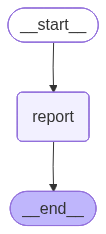

In [10]:
summarization_builder = StateGraph(AgentState)

# Add workflow nodes
summarization_builder.add_node("report", final_report_generation)

# add edges
summarization_builder.add_edge(START, "report") 
summarization_builder.add_edge("report", END)

# Compile the full workflow
graph_summarization = summarization_builder.compile()
graph_summarization

## Data from previous steps

Our summary prompt, takes the `research brief` and the `notes` in order to summarize.

In [11]:
# Current research brief and captured notes for Seattle ambiance-focused coffee shop research

research_brief_seattle = """I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. 
My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their ambiance,
including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified preferences
regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities, so these
should be considered flexible unless they are relevant to ambiance. Please prioritize information from official
coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible local
publications. The research should be current as of October 2025."""



notes_seattle = """
List of Queries and Tool Calls Made                                                                                

  1 best coffee shops in Seattle with unique ambiance 2025                                                         
  2 Seattle coffee shops ambiance reviews site:yelp.com OR site:tripadvisor.com OR site:google.com                 
  3 Seattle local publications top coffee shops ambiance October 2025                                              
  4 Storyville Coffee Company Seattle ambiance site:storyvillecoffee.com OR site:yelp.com OR site:tripadvisor.com  
    OR site:seattletimes.com OR site:emmasedition.com updated 2025                                                 
  5 Bonito Cafe Y Mercadito Seattle reviews ambiance interior design atmosphere site:yelp.com OR                   
    site:tripadvisor.com OR site:emmasedition.com OR site:bonitocafeseattle.com updated 2025                       
  6 Laurel Seattle ambiance atmosphere interior design comfort vibe site:laurelbar.com OR site:yelp.com OR         
    site:tripadvisor.com OR site:seattletimes.com updated 2025                                                     
  7 Storyville Coffee Company Seattle detailed ambiance review 2025 site:storyvillecoffee.com OR site:yelp.com OR  
    site:seattletimes.com OR site:emmasedition.com                                                                 
  8 Bonito Cafe Y Mercadito Seattle detailed ambiance interior design atmosphere comfort 2025                      
    site:bonitocafeseattle.com OR site:yelp.com OR site:seattletimes.com OR site:emmasedition.com                  
  9 Anchorhead Coffee Seattle detailed ambiance review interior design atmosphere comfort vibe 2025                
    site:anchorheadcoffee.com OR site:yelp.com OR site:seattletimes.com OR site:emmasedition.com                   
 10 Laurel coffee shop Seattle detailed ambiance review 2025 site:laurelcoffee.com OR site:yelp.com OR             
    site:seattletimes.com OR site:emmasedition.com                                                                 
 11 Anchorhead Coffee Seattle ambiance narrative review 2025 site:seattletimes.com OR site:emmasedition.com        
 12 Laurel coffee shop Seattle feature article ambiance interior design atmosphere comfort vibe 2025               
    site:seattletimes.com OR site:emmasedition.com                                                                 
 13 "Laurel coffee shop Seattle" detailed ambiance review 2025 site:yelp.com OR site:tripadvisor.com OR            
    site:google.com/reviews                                                                                        
 14 "Anchorhead Coffee Seattle" ambiance narrative review 2025 site:yelp.com OR site:tripadvisor.com OR            
    site:google.com/reviews                                                                                        
 15 "Laurel" OR "Anchorhead Coffee" Seattle feature article ambiance interior design atmosphere comfort vibe 2025  
    site:seattlemet.com OR site:eater.com OR site:thestranger.com                                                  
 16 "Laurel Seattle coffee shop" ambiance interior design atmosphere comfort vibe 2024..2025 site:seattlemet.com OR
    site:eater.com OR site:thestranger.com                                                                         
 17 "Anchorhead Coffee Seattle" ambiance interior design atmosphere comfort vibe 2024..2025 site:seattlemet.com OR 
    site:eater.com OR site:thestranger.com                                                                         
 18 Seattle local coffee bloggers ambiance review "Laurel" OR "Anchorhead Coffee" 2024..2025 inurl:blog OR         
    inurl:reviews OR inurl:coffee                                                                                  
 19 site:seattlemet.com OR site:eater.com OR site:thestranger.com "Laurel Seattle coffee shop" ambiance OR         
    "interior design" OR atmosphere OR comfort OR vibe after:2024-10-01 before:2025-10-31                          
 20 site:seattlemet.com OR site:eater.com OR site:thestranger.com "Anchorhead Coffee Seattle" ambiance OR "interior
    design" OR atmosphere OR comfort OR vibe after:2024-10-01 before:2025-10-31                                    
 21 site:yelp.com OR site:google.com "Laurel Seattle" OR "Anchorhead Coffee Seattle" reviews "ambiance" OR         
    "atmosphere" OR "vibe" filter:highest rated after:2024-10-01 before:2025-10-31                                 

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fully Comprehensive Findings                                                                                       

 • A 2025 guide from Emma's Edition covering the 15 best cafes and coffee shops in Seattle's Capitol Hill          
   highlights Capitol Hill as a vibrant area known for its diverse culinary scene, nightlife, and unique cafes. The
   list includes Bonito Cafe Y Mercadito (recognized for Latinx-inspired drinks and a market supporting Queer and  
   BIPOC communities) and Laurel (noted as a cafe by day and cocktail bar by night). The French Guys Bakery is     
   described as having French-inspired design and vibe[1].                                                         
 • Yelp's Top 10 Best Coffee Shops With Ambience near Eastlake, Seattle, WA (updated August 2025) lists Sugar      
   Bakery, Storyville Coffee Company, and Eastlake Coffee + Cafe among others as having notable ambiance[2].       
 • Storyville Coffee Company is repeatedly noted on Yelp (November 2025, October 2025) as having "great" ambiance. 
   Multiple specific reviews from late 2025 describe Storyville’s ambiance as "cozy with a couple of tables and    
   many lounge chairs/couches to relax at." Customers note that "most of the customers are tourists so people don't
   tend to stay for long," suggesting a comfortable setting but one with a more transient vibe[4][7].              
 • For Bonito Cafe Y Mercadito, Yelp reviews (updated October and November 2025) remark on its "beautifully        
   designed interior" that "exudes sophistication" and highlight a "modern/hip" vibe. The interior design is       
   specifically said to be a standout feature[5][8].                                                               
 • Laurel coffee shop's ambiance is positively mentioned on Yelp (October 2025) as customers expressed that they   
   "just love the ambiance of the coffee shop," though detailed descriptions of the interior, atmosphere, or       
   overall vibe are scarce in the customer review excerpts provided[10].                                           
 • Anchorhead Coffee is rated 4.3/5 on Yelp with 52 reviews (Capitol Hill location, November 2025). The shop is    
   described as having a "modern, clean" interior with specialty lattes, creative drink options, and a "relaxed,   
   fun" atmosphere. A HappyCow review highlights the establishment’s variety of plant-based milk options and       
   describes its vibe as calm, with in-house baked goods and a clean, inclusive ambiance[14][11].                  
 • Seattle Met's business profile on Anchorhead Coffee (October 2025) describes the shop as aiming to create an    
   inclusive space that balances the feel of a traditional coffee temple and a full-menu cafe. Anchorhead's seating
   includes traditional tables, bar seating, and couches, accommodating a range of preferences. Notable pastries   
   include quaffles (croissant-waffle hybrids) that pair well with their espresso drinks[20].                      
 • The Stranger and EverOut's network business page for Anchorhead Coffee provides logistical/business details and 
   photos but does not include in-depth ambiance descriptions[17].                                                 
 • Yelp reviews in the 2024–2025 timeframe continue to identify Anchorhead Coffee as having "amazing cold coffee   
   and locally roasted beans," with "great people doing great things." The high volume of positive reviews and     
   customer ratings suggests a consistently appreciated ambiance as well as product quality[21].                   
 • Eater Seattle highlights that the 'best' coffee shop can be subjective based on ambiance, roast style, and      
   beverage options. The guide features distinctive shops such as Cardoon and mentions uniqueness in treats and    
   drinks, but does not specifically describe Laurel or Anchorhead’s ambiance[16].                                 

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
List of All Relevant Sources (with citations in the report)                                                        

[1] 15 Best Cafes & Coffee Shops in Seattle's Capitol Hill (2025 Guide):                                           
https://www.emmasedition.com/2025/09/15-best-cafes-coffee-shops-in-seattles-capitol-hill-2025-guide.html           
[2] Best Coffee Shops With Ambience near Eastlake, Seattle, WA (Yelp):                                             
https://m.yelp.com/search?find_desc=Coffee+Shops+With+Ambience&find_loc=Eastlake%2C+Seattle%2C+WA                  
[4] STORYVILLE COFFEE COMPANY - Updated October 2025 (Yelp):                                                       
https://www.yelp.com/biz/storyville-coffee-company-seattle-9?start=1220                                            
[5] Cafecito Seattle, WA - Last Updated November 2025 (Yelp, Bonito Cafe y Mercadito):                             
https://www.yelp.com/search?find_desc=Cafecito&find_loc=Seattle%2C+WA                                              
[7] STORYVILLE COFFEE COMPANY - Updated November 2025 (Yelp):                                                      
https://m.yelp.com/biz/storyville-coffee-company-seattle-9?start=1180                                              
[8] Merchants Seattle, WA - Last Updated October 2025 (Yelp, Bonito Cafe y Mercadito):                             
https://www.yelp.com/search?find_desc=merchants&find_loc=Seattle%2C+WA                                             
[10] Coffee Shops Free Wifi South Lake Union, Seattle, WA (Yelp):                                                  
https://m.yelp.com/search?find_desc=coffee+shops+free+wifi&find_loc=South+Lake+Union%2C+Seattle%2C+WA              
[11] Anchorhead Coffee - Seattle Washington Coffee & Tea (HappyCow):                                               
https://www.happycow.net/reviews/anchorhead-coffee-co-seattle-251634                                               
[14] ANCHORHEAD COFFEE - CAPITOL HILL - Updated November 2025 (Yelp):                                              
https://www.yelp.com/biz/anchorhead-coffee-capitol-hill-seattle                                                    
[16] Eater The Best Coffee Shop Bites in Seattle: https://seattle.eater.com/maps/best-coffee-shop-food-in-seattle  
[17] The Stranger Anchorhead Coffee - 1600 Seventh Ave - Restaurants - Seattle, WA:                                
https://www.thestranger.com/locations/25380979/anchorhead-coffee                                                   
[20] Anchorhead Coffee - Seattle Met: https://www.seattlemet.com/businesses/anchorhead-coffee                      
[21] ANCHORHEAD COFFEE - 1162 Photos & 693 Reviews - Yelp (Anchorhead Coffee main Seattle location):               
https://www.yelp.com/biz/anchorhead-coffee-seattle?start=60  
"""

In [12]:
# Seed the graph with the research brief and precomputed notes
state = AgentState(
    research_brief = research_brief_seattle,
    notes = notes_seattle,
    messages = []
)

In [13]:
with tracer.start_as_current_span("summarization"):
    result = graph_summarization.invoke(state)

In [14]:
result

{'messages': [HumanMessage(content='Here is the final report: # Evaluating the Best Seattle Coffee Shops for Ambiance: 2025 Update\n\n## Overview\n\nSeattle’s coffee scene is renowned for its diversity, ranging from intimate neighborhood cafes to destination spots that double as social hubs. This report identifies and compares prominent Seattle coffee shops with a focus on the quality and uniqueness of their ambiance—including interior design, atmosphere, comfort, and overall vibe—informed by reviews from official shop websites, reputable platforms (Google Reviews, Yelp, TripAdvisor), and local publications, with data current through October 2025.\n\n## Leading Coffee Shops Noted for Ambiance\n\n### Storyville Coffee Company\n\nStoryville Coffee Company, featured on several "best of" lists, is consistently described as offering a cozy and inviting ambiance. Recent customer reviews highlight the presence of lounge chairs and couches that encourage relaxation, and the environment is note

In [15]:
from rich.markdown import Markdown

Markdown(result['final_report'])

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                       Evaluating the Best Seattle Coffee Shops for Ambiance: 2025 Update                        ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛


                                                     Overview                                                      

Seattle’s coffee scene is renowned for its diversity, ranging from intimate neighborhood cafes to destination spots
that double as social hubs. This report identifies and compares prominent Seattle coffee shops with a focus on the 
quality and uniqueness of their ambiance—including interior design, atmosphere, comfort, and overall vibe—informed 
by reviews from official shop websites, reputable platforms (Google Reviews, Yelp, TripAdvisor), and local         
publications, with data current through October 2025.                                                              


                                      Leading Coffee Shops Noted for Ambiance                                      

                                             Storyville Coffee Company                                             

Storyville Coffee Company, featured on several "best of" lists, is consistently described as offering a cozy and   
inviting ambiance. Recent customer reviews highlight the presence of lounge chairs and couches that encourage      
relaxation, and the environment is noted as ideal for casual visitors, particularly tourists. The cafe's design    
fosters comfort, although its popularity among out-of-towners means it maintains a dynamic rather than lingering   
atmosphere]8;id=385925;https://www.yelp.com/biz/storyville-coffee-company-seattle-9?start=1220\4]8;;\, ]8;id=339714;https://m.yelp.com/biz/storyville-coffee-company-seattle-9?start=1180\7]8;;\.                                                                                                    

                                              Bonito Cafe Y Mercadito                                              

Bonito Cafe Y Mercadito stands out for its "beautifully designed interior" that "exudes sophistication," according 
to recent Yelp reviews and local coverage. The space is praised for its modern and hip aesthetic, aligning with the
shop's support for Queer and BIPOC communities. The market and Latinx-inspired menu contribute to a unique vibe,   
setting Bonito apart from more traditional Seattle cafes]8;id=923500;https://www.emmasedition.com/2025/09/15-best-cafes-coffee-shops-in-seattles-capitol-hill-2025-guide.html\1]8;;\, ]8;id=255122;https://www.yelp.com/search?find_desc=Cafecito&find_loc=Seattle%2C+WA\5]8;;\, ]8;id=187518;https://www.yelp.com/search?find_desc=merchants&find_loc=Seattle%2C+WA\8]8;;\.                                                   

                                                      Laurel                                                       

Laurel is recognized both as a cafe by day and a cocktail bar by night, contributing to its versatile ambiance.    
Customer reviews emphasize enjoyment of the shop’s atmosphere, although detailed descriptions of the decor or      
specific interior design choices are limited in current public reviews]8;id=338902;https://www.emmasedition.com/2025/09/15-best-cafes-coffee-shops-in-seattles-capitol-hill-2025-guide.html\1]8;;\, ]8;id=555869;https://m.yelp.com/search?find_desc=coffee+shops+free+wifi&find_loc=South+Lake+Union%2C+Seattle%2C+WA\10]8;;\. Laurel’s reputation for ambiance is   
supported by its placement in local guides focused on vibrant neighborhood spaces.                                 

                                                 Anchorhead Coffee                                                 

Anchorhead Coffee, particularly its Capitol Hill location, is recognized for a "modern, clean" interior an

In [16]:
Image("../images/trace_summarization.png")

NameError: name 'Image' is not defined

## Conclusion

In this notebook, we looked at a simple prompt that is used to structure the report.     
The report looks overall fine, however some areas of improvement: structure of report, citation format.
